# Variant 2 — DistilGPT-2 Fine-Tuning for Domain-Conditioned Generation
**DS4 ACT4 — Multi-Variant Text Analysis and Generation**
Group 1, CSS182-04 CM2

This notebook fine-tunes `distilgpt2` as a causal language model on the cleaned financial-news
tweets, so that given a short domain prompt (e.g. a ticker placeholder or a sentiment cue) it
generates a contextually plausible continuation. We report Perplexity (from validation loss) and
BLEU/ROUGE-L of generated continuations against held-out real tweets, per the activity's
generative evaluation requirements.

In [16]:
# Colab convenience install — comment out if requirements.txt is already installed
# !pip install -q transformers datasets evaluate sacrebleu rouge-score nltk


In [17]:
# Core imports
import os                                                   # paths for saving outputs
import json                                                 # metrics serialization
from pathlib import Path                                      # robust project-relative paths
import math                                                 # perplexity = exp(loss)
import numpy as np                                          # numeric ops
import pandas as pd                                         # reading shared CSV splits
import matplotlib.pyplot as plt                              # loss curve plotting
import torch                                                 # tensor backend

from datasets import Dataset                                 # HF dataset wrapper
from transformers import (
    GPT2TokenizerFast,                                       # BPE tokenizer for GPT-2 family
    GPT2LMHeadModel,                                          # causal LM head
    DataCollatorForLanguageModeling,                          # dynamic batching/padding for LM
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import evaluate                                               # HF evaluate library for BLEU/ROUGE

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## 1. Load the shared preprocessed splits

In [18]:

# Resolve paths robustly whether the notebook is launched from the repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "dataset").exists() and (PROJECT_ROOT.parent / "dataset").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "dataset"
RESULTS_DIR = PROJECT_ROOT / "results"

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

# Avoid tokenizer/generation errors if a cleaned tweet is missing.
for df in (train_df, val_df, test_df):
    df["clean_text"] = df["clean_text"].fillna("").astype(str)
    df["sentiment"] = df["sentiment"].fillna("Neutral").astype(str)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
train_df[["clean_text", "sentiment"]].head()


Train: 9425 | Val: 1194 | Test: 1194


,clean_text,sentiment
0,<STOCK> - JPMorgan reels in expectations on Be...,Bearish
1,<STOCK> <STOCK> - Nomura points to bookings we...,Bearish
2,"<STOCK> - Cemex cut at Credit Suisse, J.P. Mor...",Bearish
3,<STOCK>: BTIG Research cuts to Neutral,Bearish
4,<STOCK> - Funko slides after Piper Jaffray PT cut,Bearish


## 2. Build domain-conditioned training sequences
We prepend a short sentiment tag to every tweet, e.g. `<Bullish> ...text...`, so the model learns to condition its continuation on a controllable prompt at generation time.

In [19]:
def build_prompted_text(row):
    # prefixes each example with its sentiment tag so the model learns prompt -> continuation
    return f"<{row['sentiment']}> {row['clean_text']}"

train_df["prompted_text"] = train_df.apply(build_prompted_text, axis=1)
val_df["prompted_text"]   = val_df.apply(build_prompted_text, axis=1)
test_df["prompted_text"]  = test_df.apply(build_prompted_text, axis=1)

train_df[["prompted_text"]].head(3)


,prompted_text
0,<Bearish> <STOCK> - JPMorgan reels in expectat...
1,<Bearish> <STOCK> <STOCK> - Nomura points to b...
2,<Bearish> <STOCK> - Cemex cut at Credit Suisse...


## 3. Tokenizer and special tokens
GPT-2 has no pad token by default, so we reuse EOS as the pad token (standard practice for causal LM fine-tuning).

In [20]:
tokenizer = GPT2TokenizerFast.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token                    # GPT-2 has no pad token; reuse EOS

# Register the sentiment control tokens as additional special tokens
SENTIMENT_TOKENS = ["<Bearish>", "<Bullish>", "<Neutral>"]
tokenizer.add_special_tokens({"additional_special_tokens": SENTIMENT_TOKENS})

MAX_LEN = 64                                                  # consistent with BERT variant's EDA-informed length

def tokenize_batch(batch):
    # appends EOS so the model learns where a tweet ends, then pads/truncates to MAX_LEN
    texts = [t + tokenizer.eos_token for t in batch["prompted_text"]]
    return tokenizer(texts, padding="max_length", truncation=True, max_length=MAX_LEN)

train_ds = Dataset.from_pandas(train_df[["prompted_text"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[["prompted_text"]].reset_index(drop=True))

train_ds = train_ds.map(tokenize_batch, batched=True, remove_columns=["prompted_text"])
val_ds   = val_ds.map(tokenize_batch, batched=True, remove_columns=["prompted_text"])

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask"])
val_ds.set_format(type="torch", columns=["input_ids", "attention_mask"])


Map: 100%|██████████| 1194/1194 [00:00<00:00, 20090.74 examples/s]


## 4. Model definition
We resize the token embedding matrix after adding the sentiment control tokens, then fine-tune the full `distilgpt2` causal LM.

In [21]:
model = GPT2LMHeadModel.from_pretrained("distilgpt2").to(device)
model.resize_token_embeddings(len(tokenizer))                 # account for the new sentiment tokens

# Causal LM collator: handles shifting input_ids -> labels internally, mlm=False = causal (not masked) LM
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 4567.98it/s]


## 5. Training arguments
Same standard callbacks as the BERT variant: early stopping on validation loss, so all three notebooks follow one shared training discipline.

In [22]:
training_args = TrainingArguments(
    output_dir=str(RESULTS_DIR / "gpt_checkpoints"),
    num_train_epochs=5,                                        # upper bound; early stopping may cut this short
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=5e-5,                                          # standard GPT-2 fine-tuning LR
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",                           # lower validation loss = better LM fit
    greater_is_better=False,
    logging_dir=str(RESULTS_DIR / "gpt_logs"),
    logging_steps=50,
    seed=SEED,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## 6. Train

In [23]:
import time

start = time.time()
train_result = trainer.train()
elapsed = time.time() - start

n_epochs_run = trainer.state.epoch
time_per_epoch = elapsed / max(n_epochs_run, 1)

print(f"Total training time: {elapsed/60:.2f} min over {n_epochs_run:.1f} epochs")
print(f"Average time/epoch : {time_per_epoch:.1f} sec")


Epoch,Training Loss,Validation Loss
1,4.248247,4.031422
2,3.798187,3.889685
3,3.489894,3.844243
4,3.407536,3.841268
5,3.342929,3.847188


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.21it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Total training time: 7.55 min over 5.0 epochs
Average time/epoch : 90.6 sec


## 7. Training history plot

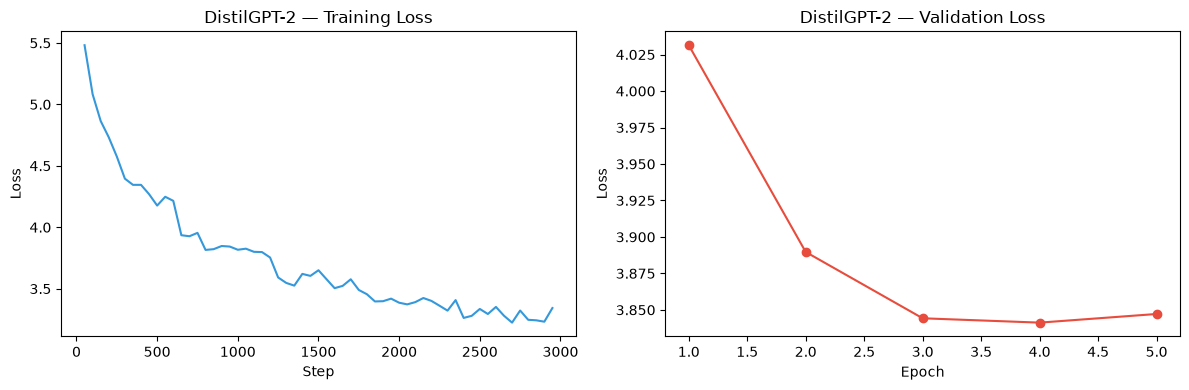

In [24]:
log_history = trainer.state.log_history
hist_df = pd.DataFrame(log_history)

history_dir = RESULTS_DIR / "training_histories"
history_dir.mkdir(parents=True, exist_ok=True)
hist_df.to_csv(history_dir / "gpt_training_history.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_loss = hist_df.dropna(subset=["loss"]) if "loss" in hist_df else pd.DataFrame()
if not train_loss.empty:
    axes[0].plot(train_loss["step"], train_loss["loss"], color="#3498db")
    axes[0].set_title("DistilGPT-2 — Training Loss")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")

eval_loss = hist_df.dropna(subset=["eval_loss"]) if "eval_loss" in hist_df else pd.DataFrame()
if not eval_loss.empty:
    axes[1].plot(eval_loss["epoch"], eval_loss["eval_loss"], marker="o", color="#e74c3c")
    axes[1].set_title("DistilGPT-2 — Validation Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.savefig(history_dir / "gpt_training_curves.png", dpi=150)
plt.show()


## 8. Perplexity
Perplexity is computed directly from the final validation cross-entropy loss:

$$\text{Perplexity} = e^{\,\mathcal{L}_{\text{val}}}$$

where $\mathcal{L}_{\text{val}}$ is the mean per-token cross-entropy loss on the validation split.
Lower perplexity means the model assigns higher probability to the true next token on average,
i.e. it predicts the held-out validation tweets more confidently.

In [25]:
eval_metrics = trainer.evaluate()
val_loss = eval_metrics["eval_loss"]
perplexity = math.exp(val_loss)

print(f"Validation loss : {val_loss:.4f}")
print(f"Perplexity      : {perplexity:.2f}")


Training Loss,Validation Loss,Epoch
3.342929,3.841268,5


Validation loss : 3.8413
Perplexity      : 46.58


## 9. Domain-conditioned generation
We sample continuations from each sentiment-conditioned prompt using nucleus (top-p) sampling, which balances fluency against generation diversity better than pure greedy decoding.

In [26]:
model.eval()                                                  # switch to inference mode

def generate_from_prompt(prompt, max_new_tokens=40, top_p=0.92, temperature=0.9, num_return=3):
    # generates `num_return` continuations for a given sentiment-conditioned prompt
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    with torch.no_grad():
        outputs = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=True,                                    # sampling, not greedy, for diverse output
            top_p=top_p,                                        # nucleus sampling threshold
            temperature=temperature,
            num_return_sequences=num_return,
            pad_token_id=tokenizer.eos_token_id,
        )
    return [tokenizer.decode(o, skip_special_tokens=True) for o in outputs]

samples = {}
for tag in SENTIMENT_TOKENS:
    samples[tag] = generate_from_prompt(tag)
    print(f"--- {tag} ---")
    for s in samples[tag]:
        print(" ", s)
    print()


--- <Bearish> ---
   <STOCK> - New York Red Bulls declares $0.14 dividend on $1.65 dividend and $0.11 dividend for 2019 and 2020, according to its corporate finance website. (
   Hedge Funds Have Never Been This Bullish On Uber Technologies Inc (TUV) Inc (UIT) Inc (UIT) Inc (UIT)? What Could Happen Next? - Bloomberg.
   <STOCK> - Unilever : Eminent Risk to Critical Health of Patients - Bulletin of Unilever Stock MarketScreener... Unilever Stock MarketScreener... Unile

--- <Bullish> ---
   <STOCK> <STOCK> - Pembina's to start processing flights for U.S. airlines this week - WSJ economy business business business economy business business finance business economy business economy
   <STOCK> (+1.0% pre) Pinnacle Pharma downgraded to Buy at B. Riley PriceScreener - S&P500: Full Results - Earnings Call Transcript.
   <STOCK> - Takeda +6% on new report of virus risk and novel adjuvant for Chinese homebuilders. Read more and get updates on any stock! economy finance trading stock

--- <Neutr

## 10. Generative quality metrics — BLEU and ROUGE-L
We generate one continuation per held-out test prompt (using its true sentiment tag) and compare it against the real tweet text that followed that tag in the test set.

In [27]:
bleu = evaluate.load("sacrebleu")
rouge = evaluate.load("rouge")

# Sample a manageable subset of the test set for generation-based scoring (generation is slow)
N_EVAL_SAMPLES = 200
eval_subset = test_df.sample(n=min(N_EVAL_SAMPLES, len(test_df)), random_state=SEED).reset_index(drop=True)

generated_texts = []
reference_texts = []

for _, row in eval_subset.iterrows():
    prompt = f"<{row['sentiment']}>"
    gen = generate_from_prompt(prompt, max_new_tokens=40, num_return=1)[0]
    # strip the leading sentiment tag so we compare generated continuation text fairly
    gen_clean = gen.replace(f"<{row['sentiment']}>", "").strip()
    generated_texts.append(gen_clean)
    reference_texts.append(row["clean_text"])

bleu_score = bleu.compute(predictions=generated_texts, references=[[r] for r in reference_texts])
rouge_score = rouge.compute(predictions=generated_texts, references=reference_texts)

print(f"BLEU      : {bleu_score['score']:.2f}")
print(f"ROUGE-L   : {rouge_score['rougeL']:.4f}")


BLEU      : 1.29
ROUGE-L   : 0.0468


## 11. Save metrics and sample outputs

In [28]:
gpt_metrics = {
    "model": "DistilGPT-2",
    "task": "domain-conditioned causal language modeling",
    "validation_loss": float(val_loss),
    "perplexity": float(perplexity),
    "bleu": float(bleu_score["score"]),
    "rouge_l": float(rouge_score["rougeL"]),
    "time_per_epoch_sec": float(time_per_epoch),
}
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
with open(RESULTS_DIR / "gpt_metrics.json", "w") as f:
    json.dump(gpt_metrics, f, indent=2)

sample_dir = RESULTS_DIR / "sample_outputs"
sample_dir.mkdir(parents=True, exist_ok=True)
with open(sample_dir / "gpt_generated_samples.txt", "w") as f:
    for tag, outs in samples.items():
        f.write(f"=== {tag} ===\n")
        for o in outs:
            f.write(o + "\n")
        f.write("\n")

print(f"Saved -> {RESULTS_DIR / 'gpt_metrics.json'}")
print(f"Saved -> {sample_dir / 'gpt_generated_samples.txt'}")
gpt_metrics


Saved -> c:\Users\dusti\Documents\Code\DS4\DS4_ACT4_MVTAnalysisNGeneration\results\gpt_metrics.json
Saved -> c:\Users\dusti\Documents\Code\DS4\DS4_ACT4_MVTAnalysisNGeneration\results\sample_outputs\gpt_generated_samples.txt


{'model': 'DistilGPT-2',
 'task': 'domain-conditioned causal language modeling',
 'validation_loss': 3.8412680625915527,
 'perplexity': 46.58450907537649,
 'bleu': 1.2872005552498873,
 'rouge_l': 0.04683769332656725,
 'time_per_epoch_sec': 90.62756056785584}

## 12. GPT Results Discussion

The DistilGPT-2 variant successfully fine-tuned a pretrained causal language model on the financial tweet dataset using sentiment-conditioned prompts. The final validation loss was **3.8413**, with a perplexity of **46.58**. Perplexity measures how uncertain the model is when predicting the next token in the validation set. A lower perplexity is better, so this result suggests that the model learned some of the dataset's language patterns, but still had noticeable uncertainty when predicting financial tweet text.

The generator achieved a BLEU score of **1.2872** and a ROUGE-L score of **0.0468**. These values are low, but this is expected for open-ended text generation on short financial tweets. BLEU and ROUGE reward exact word or phrase overlap with reference text, while GPT may generate a different but still plausible continuation. Because there are many possible valid financial headlines or tweet continuations for the same sentiment prompt, low n-gram overlap does not automatically mean the generated text is completely unusable.

## 13. Generated Text Quality

The generated samples were more fluent than the GAN outputs because DistilGPT-2 already has pretrained language knowledge. The model was able to produce recognizable financial-news style text, including stock-like placeholders, company references, market movement language, dividend mentions, earnings-style phrasing, and common finance terms such as `markets`, `trading`, `economy`, and `stocks`.

However, the generated samples still showed several weaknesses. Some outputs repeated phrases or words, such as repeated company names or repeated finance-related terms. Some generations were grammatically readable but factually unreliable, such as invented company events, unusual ticker/company combinations, or exaggerated market statements. This is a common limitation of language models: they can produce text that sounds realistic without verifying whether the content is true.

The model also sometimes drifted away from the intended sentiment. For example, a prompt labeled `<Bearish>` may still produce text that sounds neutral or even positive because the model is generating based on learned token probabilities rather than performing strict sentiment control. The sentiment tags help guide the model, but they do not guarantee perfect control over the generated continuation.

## 14. Perplexity, BLEU, and ROUGE Interpretation

Perplexity is the most direct metric for this GPT variant because the model is trained with a next-token prediction objective. The perplexity of **46.58** means that, on average, the model still considers many possible next tokens plausible at each step. This is understandable because financial tweets are short, varied, and often contain tickers, company names, numbers, abbreviations, and news-specific wording.

BLEU and ROUGE-L provide a rough estimate of textual overlap between generated samples and real held-out tweets. The low BLEU and ROUGE-L scores indicate that the generated outputs did not closely match the exact wording of the test references. However, these metrics are limited for open-ended generation because a generated tweet can be semantically reasonable while using different words from the reference tweet.

For this reason, the GPT results should be interpreted using both quantitative and qualitative evidence. The metrics show that the model is not perfectly reproducing the held-out text distribution, while the generated samples show that it learned the style and vocabulary of financial tweets better than a model trained from scratch.

## 15. Prompt Conditioning and Tokenization Effects

The notebook used sentiment tags such as `<Bearish>`, `<Bullish>`, and `<Neutral>` at the beginning of each training example. This gave the model a simple form of controlled generation. During inference, the sentiment tag acts as a prompt that nudges the model toward language associated with that class.

DistilGPT-2 uses byte-pair encoding tokenization, which is helpful for financial tweet data because it can represent unfamiliar company names, ticker-like strings, numbers, and abbreviations by splitting them into smaller subword units. This avoids the heavy `<UNK>` problem seen in simpler vocabulary-based models. As a result, GPT can produce more readable text even when the dataset contains noisy or domain-specific tokens.

At the same time, tokenization does not solve factuality or repetition. The model can generate fluent subword sequences, but it does not verify whether a stock event, dividend, downgrade, or market claim is real. This means generated outputs should be treated as synthetic text examples, not factual financial statements.

## 16. GPT Variant Summary

Overall, the GPT variant achieved the main goal of domain-conditioned text generation. It fine-tuned DistilGPT-2 on the financial tweet corpus, generated sentiment-conditioned samples, and produced measurable validation loss, perplexity, BLEU, and ROUGE-L scores.

The results show that GPT is effective at learning the style and vocabulary of financial tweets, but the generated text still has limitations. The samples are often readable and finance-themed, yet they can repeat phrases, drift from the sentiment prompt, or fabricate realistic-sounding but unreliable financial claims.

For this notebook, GPT should be interpreted as a stronger generative model than a from-scratch adversarial text generator because it benefits from large-scale pretraining and direct next-token supervision. Its main weakness is not fluency, but reliability and exact-match similarity to real held-out tweets.


## References

* **Model Architecture:** Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019). *Language Models are Unsupervised Multitask Learners*. OpenAI.
* **Distillation Technique:** Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). *DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter*. arXiv preprint arXiv:1910.01108. (Basis for DistilGPT-2). [https://arxiv.org/abs/1910.01108](https://arxiv.org/abs/1910.01108)
* **Evaluation (BLEU):** Post, M. (2018). *A Call for Clarity in Reporting BLEU Scores*. In Proceedings of the Third Conference on Machine Translation: Research Papers (pp. 186-191). [https://aclanthology.org/W18-6319/](https://aclanthology.org/W18-6319/)
* **Evaluation (ROUGE):** Lin, C.-Y. (2004). *ROUGE: A Package for Automatic Evaluation of Summaries*. In Text Summarization Branches Out (pp. 74-81). [https://aclanthology.org/W04-1013/](https://aclanthology.org/W04-1013/)